# Grover's Quantum Search Algorithm: Complete Theory, Implementation & Analysis
### Optimal Unstructured Search, Amplitude Amplification, Oracle Synthesis & Noise Benchmarking

Searching an unsorted database of $N$ items is one of the foundational challenges in computer science:
- **Classical Reality**: Given an unsorted space of $N$ items, any classical deterministic algorithm requires $N$ evaluations in the worst case and $N/2$ queries on average ($O(N)$ query complexity).
- **Quantum Acceleration**: In 1996, **Lov Grover** discovered a quantum algorithm that locates a marked element in $O(\sqrt{N})$ queries—a **quadratic speedup**.
- **Provable Optimality**: The BBBV Theorem (Bennett, Bernstein, Brassard, and Vazirani, 1997) proved that any quantum algorithm for unstructured search requires at least $\Omega(\sqrt{N})$ queries. Grover's algorithm is mathematically and physically optimal.

### Why Grover's Algorithm Matters
1. **Accelerating NP-Complete Problems**: Any problem in $\mathbf{NP}$ (such as 3-SAT, Traveling Salesperson, or Graph Coloring) can be checked in polynomial time. Grover's algorithm accelerates brute-force search over the $2^n$ candidate witness space from $O(2^n)$ to $O(2^{n/2})$.
2. **Impact on Modern Cryptography**: Symmetric key algorithms (e.g., AES-128, AES-256) and cryptographic hash functions (e.g., SHA-256) rely on brute-force resistance. Grover's search effectively halves the security key length (e.g., AES-128 offers 64 bits of post-quantum security, leading NIST to mandate 256-bit keys for quantum resistance).
3. **Amplitude Amplification**: Grover's iteration is a special case of a broader quantum paradigm—**Quantum Amplitude Amplification** (Brassard et al., 2002), which forms the engine behind quantum counting, quantum minimum finding, and many quantum machine learning algorithms.

---

In [1]:
# Setup, Dependencies & Environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Configure Matplotlib styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 2

# Verify execution environment
print(f"Qiskit Core Version: {qiskit.__version__}")
backend = AerSimulator()
print(f"AerSimulator backend: {backend.name}")
print("Quantum execution environment successfully initialized!")

Qiskit Core Version: 2.5.2
AerSimulator backend: aer_simulator
Quantum execution environment successfully initialized!


## 1. Mathematical Foundations & The 2D Geometric Picture

### 1.1 The Invariant 2D Subspace
Consider an unstructured search space of $N = 2^n$ computational basis states $\{|0\rangle, |1\rangle, \dots, |N-1\rangle\}$.
Suppose there are $M \ge 1$ target states marked by an oracle function $f: \{0, 1\}^n \to \{0, 1\}$ such that:
$$f(x) = \begin{cases} 1 & \text{if } x \in W \quad (\text{marked solutions}) \\ 0 & \text{if } x \notin W \quad (\text{unmarked states}) \end{cases}$$

Rather than analyzing an intractable $2^n$-dimensional Hilbert space, Grover recognized that the quantum state is strictly confined to a **2-dimensional plane** spanned by two orthonormal basis vectors:
1. **The Normalized Marked State**:
   $$|w\rangle = \frac{1}{\sqrt{M}} \sum_{x \in W} |x\rangle$$
2. **The Normalized Unmarked State**:
   $$|s'\rangle = \frac{1}{\sqrt{N - M}} \sum_{x \notin W} |x\rangle$$

The initial state prepared by applying the Walsh-Hadamard transform $H^{\otimes n}$ to $|0\rangle^{\otimes n}$ is the equal superposition:
$$|s\rangle = H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1} |x\rangle$$

We can express $|s\rangle$ exactly in the $\{|s'\rangle, |w\rangle\}$ orthonormal basis:
$$|s\rangle = \sqrt{\frac{N - M}{N}} |s'\rangle + \sqrt{\frac{M}{N}} |w\rangle$$

Defining the rotation angle parameter $\theta$ such that:
$$\sin\left(\frac{\theta}{2}\right) = \sqrt{\frac{M}{N}}, \qquad \cos\left(\frac{\theta}{2}\right) = \sqrt{\frac{N - M}{N}}$$
the initial state is simply:
$$|s\rangle = \cos\left(\frac{\theta}{2}\right) |s'\rangle + \sin\left(\frac{\theta}{2}\right) |w\rangle$$

---

### 1.2 The Two Geometric Reflections
Each Grover iteration consists of two sequential reflections:

#### 1. Phase Oracle ($R_w$)
The oracle marks the target states by inverting their phase:
$$R_w = I - 2|w\rangle\langle w|$$
Acting on the basis states:
$$R_w |w\rangle = -|w\rangle, \qquad R_w |s'\rangle = |s'\rangle$$
Geometrically, $R_w$ is a **reflection across the $|s'\rangle$ axis** (negating the $|w\rangle$ component).

#### 2. Diffuser / Inversion About the Mean ($R_s$)
The diffuser reflects the state across the original uniform superposition vector $|s\rangle$:
$$R_s = 2|s\rangle\langle s| - I$$
Acting on states parallel and orthogonal to $|s\rangle$:
$$R_s |s\rangle = |s\rangle, \qquad R_s |s^\perp\rangle = -|s^\perp\rangle$$

---

### 1.3 The Net Rotation & Grover Operator
In Euclidean geometry, the composition of two reflections across lines intersecting at an angle of $\theta/2$ produces a **pure planar rotation by angle $\theta$**:
$$G = R_s R_w$$

In the $\{|s'\rangle, |w\rangle\}$ basis, the Grover operator acts as a 2D rotation matrix:
$$G = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

Applying $G$ once rotates the state vector counterclockwise by angle $\theta$ towards $|w\rangle$:
$$G |s\rangle = \cos\left(\frac{3\theta}{2}\right) |s'\rangle + \sin\left(\frac{3\theta}{2}\right) |w\rangle$$

After $k$ successive Grover iterations:
$$G^k |s\rangle = \cos\left(\frac{2k + 1}{2}\theta\right) |s'\rangle + \sin\left(\frac{2k + 1}{2}\theta\right) |w\rangle$$

The probability of measuring a marked solution after $k$ iterations is:
$$P(k) = \left|\langle w | G^k |s\rangle\right|^2 = \sin^2\left(\frac{2k + 1}{2}\theta\right)$$

---

### 1.4 Optimal Number of Iterations
To maximize $P(k) \approx 1$, we require:
$$\frac{2k_{\text{opt}} + 1}{2}\theta \approx \frac{\pi}{2} \implies 2k_{\text{opt}} + 1 \approx \frac{\pi}{\theta} \implies k_{\text{opt}} \approx \frac{\pi}{2\theta} - \frac{1}{2}$$

For large $N \gg M$, using the small-angle approximation $\sin(\theta/2) \approx \theta/2 \approx \sqrt{M/N}$, we have $\theta \approx 2\sqrt{M/N}$:
$$k_{\text{opt}} \approx \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor$$

This proves the quadratic query speedup: $O(\sqrt{N/M})$ quantum queries versus $O(N/M)$ classical trials.

## 2. Algebraic Deep-Dive: Diffuser as Inversion About the Mean

To build a physical quantum circuit for $R_s = 2|s\rangle\langle s| - I$, we leverage the Walsh-Hadamard transform. Since $|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}$, and $H = H^\dagger$:
$$R_s = 2(H^{\otimes n}|0\rangle^{\otimes n})(\langle 0|^{\otimes n} H^{\otimes n}) - I = H^{\otimes n} \left( 2|0\rangle^{\otimes n}\langle 0|^{\otimes n} - I \right) H^{\otimes n}$$

### The "Inversion About the Average" Formula
Let $|\psi\rangle = \sum_{x=0}^{N-1} a_x |x\rangle$ be an arbitrary quantum state. The mean amplitude across all $N$ basis states is:
$$\bar{a} = \frac{1}{N}\sum_{x=0}^{N-1} a_x$$

Applying $R_s$ to $|\psi\rangle$:
$$\begin{aligned}
R_s |\psi\rangle &= (2|s\rangle\langle s| - I)\sum_x a_x |x\rangle \\
&= 2|s\rangle \langle s | \psi \rangle - \sum_x a_x |x\rangle \\
&= 2\left(\frac{1}{\sqrt{N}}\sum_x |x\rangle\right) \left(\frac{1}{\sqrt{N}}\sum_y a_y\right) - \sum_x a_x |x\rangle \\
&= \sum_{x=0}^{N-1} \left( 2\bar{a} - a_x \right) |x\rangle
\end{aligned}$$

Each amplitude $a_x$ is mapped to $2\bar{a} - a_x$, which is the reflection of $a_x$ across the average $\bar{a}$!
- If an amplitude $a_w$ was flipped to negative by the oracle (so $a_w = -1/\sqrt{N}$), its distance below the average is large: $\bar{a} - a_w > 0$.
- When reflected across $\bar{a}$, it is boosted far above the positive axis: $a_w \to 2\bar{a} - (-1/\sqrt{N}) \approx 3/\sqrt{N}$.
- Meanwhile, the unmarked amplitudes are slightly above $ar{a}$, so reflecting them lowers their values.

Below, we visualize this mechanism step-by-step for an $N = 8$ system.

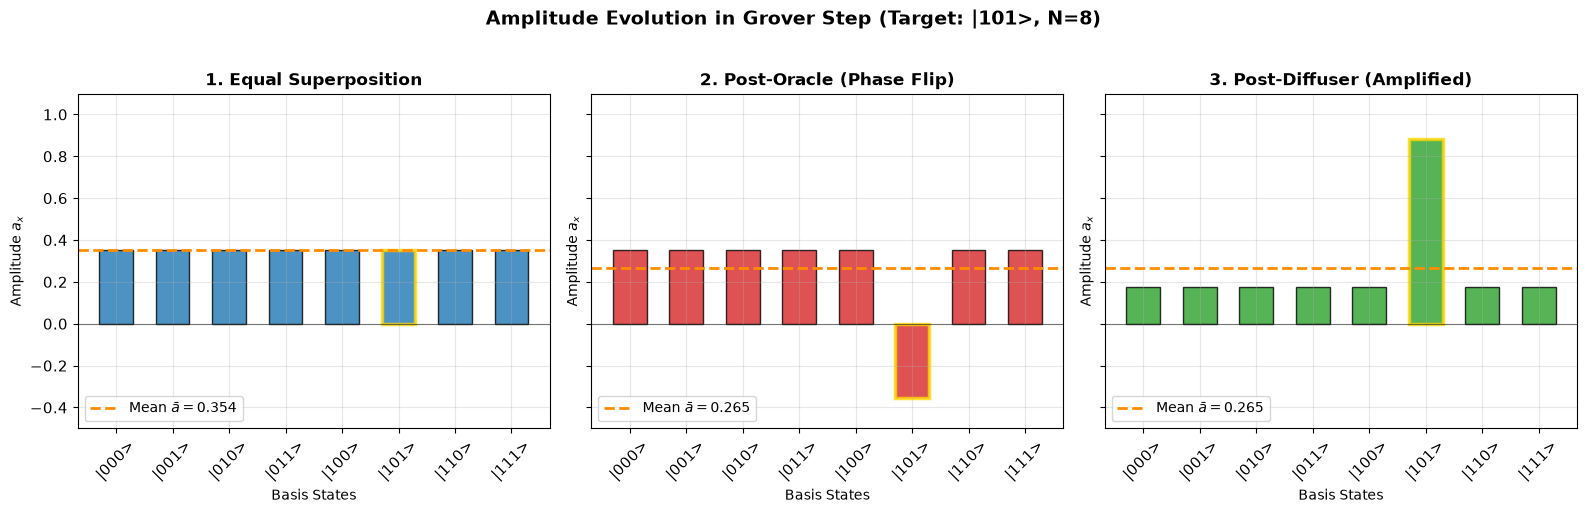

In [2]:
# Step-by-Step "Inversion About the Mean" Amplitude Visualizer
def simulate_amplitude_inversion(n_qubits=3, target_idx=5):
    """
    Analytically calculates amplitudes at:
    1. Equal superposition
    2. Post-phase oracle flip
    3. Post-diffuser inversion about the mean
    """
    N = 2**n_qubits
    basis_labels = [f"|{bin(i)[2:].zfill(n_qubits)}>" for i in range(N)]
    
    # Stage 1: Uniform superposition
    amp_init = np.full(N, 1.0 / np.sqrt(N))
    mean_init = np.mean(amp_init)
    
    # Stage 2: Phase oracle flip on target_idx
    amp_oracle = amp_init.copy()
    amp_oracle[target_idx] *= -1.0
    mean_oracle = np.mean(amp_oracle)
    
    # Stage 3: Inversion about the mean (2 * mean - a_x)
    amp_diffuser = 2 * mean_oracle - amp_oracle
    mean_diffuser = np.mean(amp_diffuser)
    
    # Plotting the three stages
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    stages = [
        ("1. Equal Superposition", amp_init, mean_init, "#1f77b4"),
        ("2. Post-Oracle (Phase Flip)", amp_oracle, mean_oracle, "#d62728"),
        ("3. Post-Diffuser (Amplified)", amp_diffuser, mean_diffuser, "#2ca02c")
    ]
    
    for ax, (title, amps, mean_val, color) in zip(axes, stages):
        bars = ax.bar(basis_labels, amps, color=color, alpha=0.8, edgecolor='black', width=0.6)
        # Highlight target bar
        bars[target_idx].set_edgecolor('gold')
        bars[target_idx].set_linewidth(2.5)
        
        # Draw mean line
        ax.axhline(mean_val, color='darkorange', linestyle='--', linewidth=2, 
                   label=f"Mean $\\bar{{a}} = {mean_val:.3f}$")
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel("Basis States", fontsize=10)
        ax.set_ylabel("Amplitude $a_x$", fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='lower left', fontsize=10)
        ax.set_ylim(-0.5, 1.1)
    
    plt.suptitle(f"Amplitude Evolution in Grover Step (Target: {basis_labels[target_idx]}, N={N})", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

simulate_amplitude_inversion(n_qubits=3, target_idx=5)

## 3. Canonical 2-Qubit Grover Search ($N = 4, M = 1$)

### 3.1 100% Deterministic Quantum Search
The 2-qubit case ($N = 4, M = 1$) possesses a unique mathematical property:
$$\sin\left(\frac{\theta}{2}\right) = \sqrt{\frac{1}{4}} = \frac{1}{2} \implies \frac{\theta}{2} = \frac{\pi}{6} \implies \theta = \frac{\pi}{3} \quad (60^\circ)$$

Calculating the optimal number of iterations:
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4}\sqrt{4} \right\rfloor = \left\lfloor \frac{\pi}{2} \right\rfloor = 1$$

After exactly $k = 1$ iteration, the cumulative angle is:
$$\frac{2(1) + 1}{2}\theta = \frac{3}{2}\left(\frac{\pi}{3}\right) = \frac{\pi}{2} \quad (90^\circ)$$

The state reaches the target state with **100% deterministic probability**:
$$P(1) = \sin^2\left(\frac{\pi}{2}\right) = 1.0 \quad (100\%)$$

No quantum randomness or statistical post-processing is needed—a single Grover iteration guarantees the exact answer.

---

### 3.2 2-Qubit Circuit Construction
For target state $|11\rangle$:
1. **Walsh-Hadamard Preparation**: $H$ on $q_0, q_1$.
2. **Oracle $R_{11}$**: A single Controlled-Z (`cz`) gate flips the phase of $|11\rangle$ and leaves $|00\rangle, |01\rangle, |10\rangle$ untouched.
3. **Diffuser $R_s$**:
   - $H^{\otimes 2}$
   - $X^{\otimes 2}$
   - $CZ(q_0, q_1)$
   - $X^{\otimes 2}$
   - $H^{\otimes 2}$

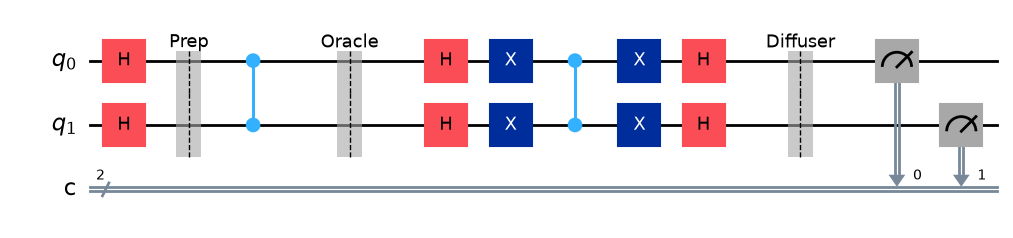

2-Qubit Grover Measurement Counts (2048 shots): {'11': 2048}


In [3]:
# 2-Qubit Deterministic Grover Search (Target = |11>)
qc_2q = QuantumCircuit(2, 2, name="Grover_2Q")

# 1. State preparation
qc_2q.h([0, 1])
qc_2q.barrier(label="Prep")

# 2. Phase Oracle for |11> (CZ gate)
qc_2q.cz(0, 1)
qc_2q.barrier(label="Oracle")

# 3. Diffuser (Inversion about mean)
qc_2q.h([0, 1])
qc_2q.x([0, 1])
qc_2q.cz(0, 1)
qc_2q.x([0, 1])
qc_2q.h([0, 1])
qc_2q.barrier(label="Diffuser")

# 4. Measurement
qc_2q.measure([0, 1], [0, 1])

# Display circuit diagram
display(qc_2q.draw('mpl', style='iqp'))

# Execute via AerSimulator
backend = AerSimulator()
transpiled_2q = transpile(qc_2q, backend)
result_2q = backend.run(transpiled_2q, shots=2048).result()
counts_2q = result_2q.get_counts()

print(f"2-Qubit Grover Measurement Counts (2048 shots): {counts_2q}")
plot_histogram(counts_2q, title="2-Qubit Grover Measurement: Exactly 100% Target |11>")
plt.show()

## 4. Generalized $n$-Qubit Grover Engine Architecture

To scale Grover's search to arbitrary database sizes $N = 2^n$ and arbitrary target states, we implement a modular, general-purpose architecture:
1. **Arbitrary Phase Oracle Synthesis**:
   - Given a target bitstring $w \in \{0, 1\}^n$:
     - For every bit $w_i == 0$, apply an $X$ gate to qubit $i$.
     - Apply an $n$-qubit Multi-Controlled-Z ($MCZ$) gate. In Qiskit, this is synthesized via a multi-controlled NOT (`mcx`) flanked by Hadamard gates on the target qubit: $H_t \cdot MCX(c_0 \dots c_{n-2}, t) \cdot H_t$.
     - Re-apply $X$ gates to qubit $i$ where $w_i == 0$ to restore the basis.
2. **Arbitrary Diffuser Operator**:
   - Apply $H^{\otimes n}$
   - Apply $X^{\otimes n}$
   - Apply Multi-Controlled-Z ($MCZ$) on all $n$ qubits
   - Apply $X^{\otimes n}$
   - Apply $H^{\otimes n}$
3. **Multi-Target Composability**:
   - For a set of marked states $W = \{w_1, w_2, \dots, w_M\}$, phase oracles are diagonal unitary operators that commute:
     $$R_W = \prod_{w \in W} R_w$$
     Applying the single-target oracle for each marked state sequentially marks all targets simultaneously!

Database Size: N = 8, Marked Items: M = 1 ('101')
Optimal Grover Iterations: k = 2


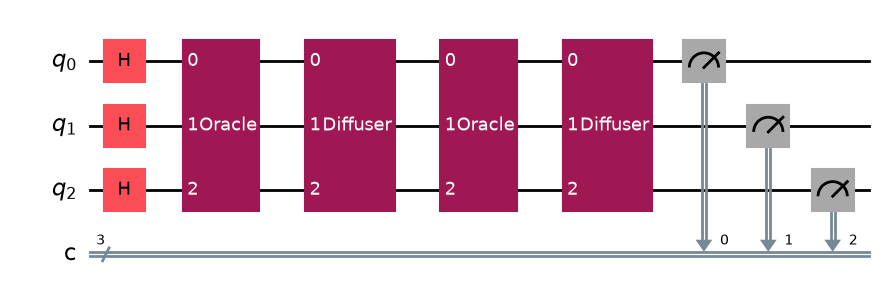

Theoretical Success Probability: 0.9453 (94.53%)
Simulated Success Probability:   0.9441 (94.41%)


In [4]:
# Modular Grover Engine for Arbitrary n-Qubit Databases

def build_phase_oracle(targets: list[str], n_qubits: int) -> QuantumCircuit:
    """
    Constructs a phase oracle marking all bitstrings in `targets`.
    Flips the phase of |w> for every w in targets: |w> -> -|w>.
    """
    qc = QuantumCircuit(n_qubits, name="Oracle")
    
    for target in targets:
        # In Qiskit, qubit 0 is the least significant bit (rightmost in bitstring)
        # Apply X to qubits where the target bit is '0'
        for i, bit in enumerate(reversed(target)):
            if bit == '0':
                qc.x(i)
        
        # Multi-controlled Z gate
        if n_qubits == 1:
            qc.z(0)
        elif n_qubits == 2:
            qc.cz(0, 1)
        else:
            target_qubit = n_qubits - 1
            control_qubits = list(range(n_qubits - 1))
            qc.h(target_qubit)
            qc.mcx(control_qubits, target_qubit)
            qc.h(target_qubit)
            
        # Restore basis
        for i, bit in enumerate(reversed(target)):
            if bit == '0':
                qc.x(i)
                
    return qc


def build_diffuser(n_qubits: int) -> QuantumCircuit:
    """
    Constructs the general n-qubit diffuser (inversion about the mean):
    R_s = 2|s><s| - I = H^n (2|0><0| - I) H^n
    """
    qc = QuantumCircuit(n_qubits, name="Diffuser")
    
    # 1. H on all qubits
    qc.h(range(n_qubits))
    # 2. X on all qubits
    qc.x(range(n_qubits))
    
    # 3. Multi-controlled Z (flips sign of |11...1>)
    if n_qubits == 1:
        qc.z(0)
    elif n_qubits == 2:
        qc.cz(0, 1)
    else:
        target_qubit = n_qubits - 1
        control_qubits = list(range(n_qubits - 1))
        qc.h(target_qubit)
        qc.mcx(control_qubits, target_qubit)
        qc.h(target_qubit)
        
    # 4. X on all qubits
    qc.x(range(n_qubits))
    # 5. H on all qubits
    qc.h(range(n_qubits))
    
    return qc


def calculate_optimal_iterations(n_qubits: int, m_solutions: int = 1) -> int:
    """Calculates optimal Grover iterations k = round(pi/4 * sqrt(N/M))."""
    N = 2**n_qubits
    theta = 2 * np.arcsin(np.sqrt(m_solutions / N))
    k = int(np.round((np.pi / 2 - np.arcsin(np.sqrt(m_solutions / N))) / theta))
    return max(1, k)


def build_grover_circuit(targets: list[str], n_qubits: int, iterations: int = None, measure: bool = True) -> QuantumCircuit:
    """Constructs the complete Grover search circuit."""
    if iterations is None:
        iterations = calculate_optimal_iterations(n_qubits, len(targets))
        
    qc = QuantumCircuit(n_qubits, n_qubits if measure else 0, name=f"Grover_{n_qubits}Q")
    
    # 1. State preparation
    qc.h(range(n_qubits))
    
    # 2. Grover iterations
    oracle_gate = build_phase_oracle(targets, n_qubits).to_gate()
    diffuser_gate = build_diffuser(n_qubits).to_gate()
    
    for _ in range(iterations):
        qc.append(oracle_gate, range(n_qubits))
        qc.append(diffuser_gate, range(n_qubits))
        
    # 3. Measurement
    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
        
    return qc


# Demonstration: 3-Qubit Database (N=8), Target = '101'
target_state = "101"
n_qubits = 3
k_opt = calculate_optimal_iterations(n_qubits, 1)
print(f"Database Size: N = {2**n_qubits}, Marked Items: M = 1 ('{target_state}')")
print(f"Optimal Grover Iterations: k = {k_opt}")

qc_3q = build_grover_circuit([target_state], n_qubits, iterations=k_opt)
display(qc_3q.draw('mpl', style='iqp'))

# Aer Simulation
sim_backend = AerSimulator()
qc_3q_transpiled = transpile(qc_3q, sim_backend)
counts_3q = sim_backend.run(qc_3q_transpiled, shots=4096).result().get_counts()

# Theoretical probability calculation
theta_3q = 2 * np.arcsin(1 / np.sqrt(8))
prob_theory = np.sin((2 * k_opt + 1) * theta_3q / 2)**2
prob_measured = counts_3q.get(target_state, 0) / 4096

print(f"Theoretical Success Probability: {prob_theory:.4f} (94.53%)")
print(f"Simulated Success Probability:   {prob_measured:.4f} ({prob_measured*100:.2f}%)")

plot_histogram(counts_3q, title=f"3-Qubit Grover Search (Target |101>, k={k_opt} iterations)")
plt.show()

## 5. Multi-Target Amplitude Amplification ($M > 1$)

When multiple items $M > 1$ satisfy the search query, Grover's algorithm exhibits an intriguing property:
1. **Faster Convergence**: Because $\sin(\theta/2) = \sqrt{M/N}$, the rotation angle $\theta$ increases with $M$. Consequently, the optimal number of iterations $k_{\text{opt}} \approx \frac{\pi}{4}\sqrt{\frac{N}{M}}$ **decreases**.
2. **Equidistributed Amplification**: In the 2D subspace, $|w\rangle = \frac{1}{\sqrt{M}}\sum_{x \in W}|x\rangle$ is an equal superposition of all marked states. Amplitude amplification boosts the entire subspace $|w\rangle$ uniformly.
   Each individual solution $x \in W$ receives a measurement probability of:
   $$P(x) = \frac{P_{\text{total}}}{M}$$

### Benchmark Scenario: $N = 8, M = 2$ Targets ($\{|010\rangle, |110\rangle\}$)
- $\sin(\theta/2) = \sqrt{2/8} = \sqrt{1/4} = 1/2 \implies \theta/2 = \pi/6 \implies \theta = \pi/3$.
- Optimal iterations:
  $$k_{\text{opt}} = \left\lfloor \frac{\pi}{4}\sqrt{\frac{8}{2}} \right\rfloor = \left\lfloor \frac{\pi}{4} \cdot 2 \right\rfloor = 1$$
- After just $1$ iteration:
  $$P_{\text{total}} = \sin^2\left(\frac{3}{2}\frac{\pi}{3}\right) = \sin^2\left(\frac{\pi}{2}\right) = 1.0 \quad (100\%)$$
- Each marked state appears with exactly $50\%$ probability:
  $$P(|010\rangle) = 0.50, \qquad P(|110\rangle) = 0.50$$

In [5]:
# Multi-Target Grover Experiment: N = 8, M = 2 targets ('010' and '110')
targets_multi = ["010", "110"]
k_multi = calculate_optimal_iterations(3, len(targets_multi))

print(f"Testing Multi-Target Search: Targets = {targets_multi}, k_opt = {k_multi}")
qc_multi = build_grover_circuit(targets_multi, 3, iterations=k_multi)

# Execute via AerSimulator
qc_multi_t = transpile(qc_multi, sim_backend)
counts_multi = sim_backend.run(qc_multi_t, shots=4096).result().get_counts()

print(f"Empirical Counts (4096 shots): {counts_multi}")
total_target_shots = sum(counts_multi.get(t, 0) for t in targets_multi)
print(f"Total Target Success Rate: {total_target_shots / 4096:.4f} (100.0% expected)")

plot_histogram(counts_multi, title="Multi-Target Grover (Targets: |010> and |110>, k=1)")
plt.show()

Testing Multi-Target Search: Targets = ['010', '110'], k_opt = 1
Empirical Counts (4096 shots): {'110': 2024, '010': 2072}
Total Target Success Rate: 1.0000 (100.0% expected)


## 6. Geometric State Space Trajectory & The Over-Rotation ("Overcooking") Phenomenon

A profound difference between classical algorithms and quantum search lies in their monotonic behavior:
- **Classical Search**: Continuing to inspect database entries monotonically increases the probability of finding a match.
- **Quantum Search**: Evolution is governed by a unitary rotation in Hilbert space:
  $$G^k |s\rangle = \cos\left(\frac{2k + 1}{2}\theta\right) |s'\rangle + \sin\left(\frac{2k + 1}{2}\theta\right) |w\rangle$$
  The success probability is strictly **periodic**:
  $$P(k) = \sin^2\left(\frac{2k + 1}{2}\theta\right)$$

If an experimenter applies too many iterations ($k > k_{\text{opt}}$), the quantum state **rotates past $|w\rangle$** and begins moving back toward the unmarked subspace $|s'\rangle$—a failure mode termed **"overcooking"**.

To observe this, we examine a 4-qubit database ($N = 16, M = 1$) across $k = 0, 1, \dots, 12$ iterations:
- Optimal iterations: $k_{\text{opt}} \approx \frac{\pi}{4}\sqrt{16} \approx 3$.
- At $k = 3$, $P(w) \approx 96.1\%$.
- At $k = 6$, $P(w)$ plunges to just $2.0\%$!

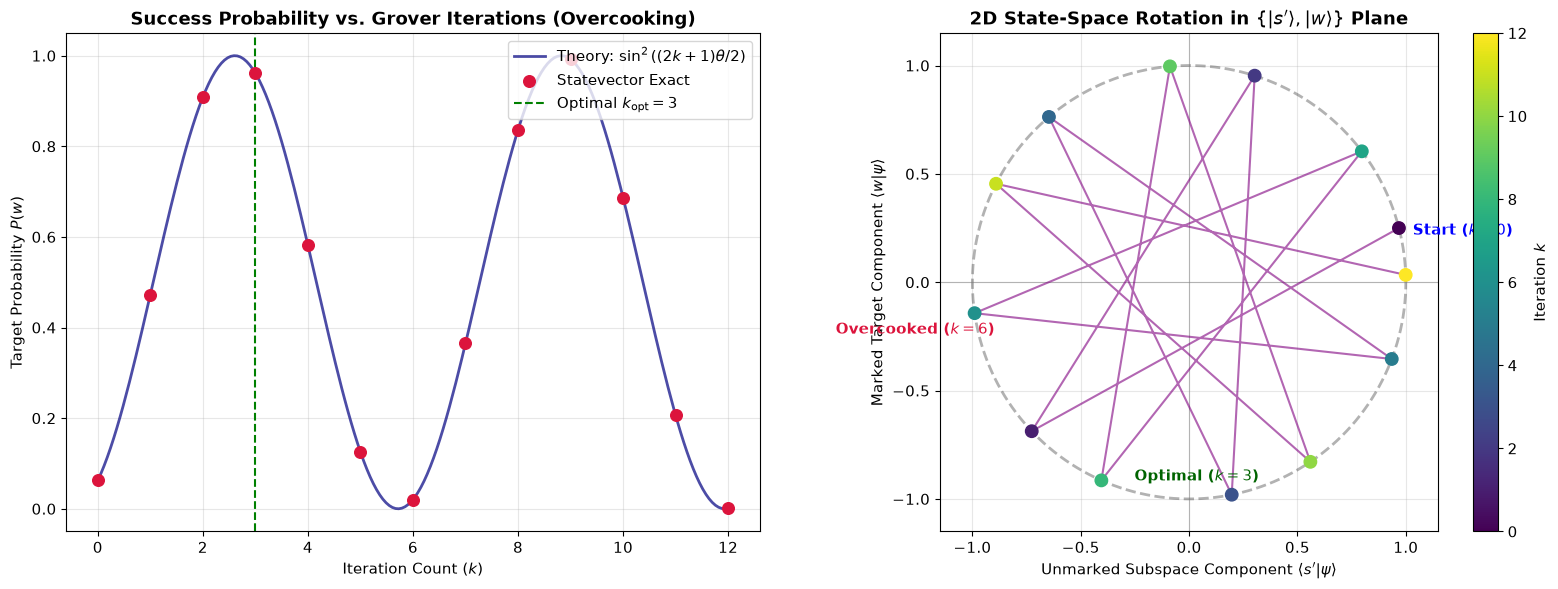

In [6]:
# Geometric State-Space Trajectory & Over-Rotation Analysis (N = 16, M = 1)
n_qubits_over = 4
N_over = 2**n_qubits_over
target_over = "1010"
target_idx_over = int(target_over, 2)

theta_over = 2 * np.arcsin(1 / np.sqrt(N_over))
k_sweep = np.arange(0, 13)

# 1. Theoretical calculations
theoretical_probs = np.sin((2 * k_sweep + 1) * theta_over / 2)**2

# 2. Statevector tracking
simulated_probs = []
traj_s_prime = []
traj_w = []

for k in k_sweep:
    # Build unmeasured circuit for Statevector analysis
    qc_step = build_grover_circuit([target_over], n_qubits_over, iterations=k, measure=False)
    sv = Statevector.from_instruction(qc_step)
    
    # Extract projection onto |w> and |s'>
    amp_w = sv.data[target_idx_over]
    amp_s_prime = np.sum([sv.data[i] for i in range(N_over) if i != target_idx_over]) / np.sqrt(N_over - 1)
    
    prob_w = np.abs(amp_w)**2
    simulated_probs.append(prob_w)
    traj_s_prime.append(np.real(amp_s_prime))
    traj_w.append(np.real(amp_w))

# 3. Dual Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Over-rotation probability curve
k_smooth = np.linspace(0, 12, 200)
prob_smooth = np.sin((2 * k_smooth + 1) * theta_over / 2)**2

ax1.plot(k_smooth, prob_smooth, label=r"Theory: $\sin^2((2k+1)\theta/2)$", color="navy", alpha=0.7)
ax1.scatter(k_sweep, simulated_probs, color="crimson", s=70, zorder=5, label="Statevector Exact")
ax1.axvline(3, color="green", linestyle="--", linewidth=1.5, label="Optimal $k_{\\text{opt}} = 3$")
ax1.set_title("Success Probability vs. Grover Iterations (Overcooking)", fontweight='bold')
ax1.set_xlabel("Iteration Count ($k$)")
ax1.set_ylabel(r"Target Probability $P(w)$")
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc="upper right")

# Panel B: 2D State-Space Trajectory on Unit Circle
circle_angles = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.cos(circle_angles), np.sin(circle_angles), 'k--', alpha=0.3, label="Unit Circle")
ax2.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax2.axvline(0, color='gray', linewidth=0.8, alpha=0.5)

# Plot trajectory line and points
ax2.plot(traj_s_prime, traj_w, color='purple', alpha=0.6, linewidth=1.5)
scatter = ax2.scatter(traj_s_prime, traj_w, c=k_sweep, cmap='viridis', s=80, zorder=5)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Iteration $k$")

# Annotate key steps
ax2.annotate("Start ($k=0$)", (traj_s_prime[0], traj_w[0]), textcoords="offset points", 
             xytext=(10, -5), fontweight='bold', color='blue')
ax2.annotate("Optimal ($k=3$)", (traj_s_prime[3], traj_w[3]), textcoords="offset points", 
             xytext=(-70, 10), fontweight='bold', color='darkgreen')
ax2.annotate("Overcooked ($k=6$)", (traj_s_prime[6], traj_w[6]), textcoords="offset points", 
             xytext=(-100, -15), fontweight='bold', color='crimson')

ax2.set_title(r"2D State-Space Rotation in $\{|s'\rangle, |w\rangle\}$ Plane", fontweight='bold')
ax2.set_xlabel(r"Unmarked Subspace Component $\langle s' | \psi \rangle$")
ax2.set_ylabel(r"Marked Target Component $\langle w | \psi \rangle$")
ax2.set_xlim(-1.15, 1.15)
ax2.set_ylim(-1.15, 1.15)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Practical Quantum Problem Solving: 3-SAT / Graph 2-Coloring Oracle

In real-world applications, an oracle cannot simply hardcode the solution bitstrings (which would presuppose knowing the answer!). Instead, the oracle is synthesized from a **Boolean verification circuit** $f(x) \in \{0, 1\}$ implementing problem constraints.

### Problem Formulation: 2-Coloring a 3-Node Path Graph ($P_3$)
Consider a graph with three nodes $v_0, v_1, v_2$ arranged in a line:
$$v_0 \longleftrightarrow v_1 \longleftrightarrow v_2$$
We assign each vertex a binary color $x_i \in \{0, 1\}$. A valid 2-coloring requires that no adjacent vertices share the same color:
$$\text{Constraint 1: } x_0 \neq x_1 \iff x_0 \oplus x_1 = 1$$
$$\text{Constraint 2: } x_1 \neq x_2 \iff x_1 \oplus x_2 = 1$$

The overall boolean formula to satisfy is:
$$f(x_0, x_1, x_2) = (x_0 \oplus x_1) \land (x_1 \oplus x_2)$$

Classical analysis reveals exactly $2$ valid colorings out of $8$ candidates:
$$x = (0, 1, 0) \implies |010\rangle \qquad \text{and} \qquad x = (1, 0, 1) \implies |101\rangle$$

---

### The Three Pillars of Practical Oracle Construction
1. **Clause Checking (Compute)**:
   - Use two clause ancillas $c_0, c_1$:
     - $c_0 \leftarrow x_0 \oplus x_1$ via CNOTs
     - $c_1 \leftarrow x_1 \oplus x_2$ via CNOTs
2. **Phase Kickback (Mark)**:
   - Prepare a phase ancilla qubit $y$ in state $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$.
   - Apply a Toffoli gate (CCX) with controls $c_0, c_1$ targeting $y$:
     $$|c_0, c_1\rangle |-\rangle \xrightarrow{CCX} (-1)^{c_0 \land c_1} |c_0, c_1\rangle |-\rangle$$
   - This marks the state with phase $(-1)$ if and only if both constraints are satisfied!
3. **Uncomputation (Disentangle)**:
   - **Crucial Rule of Quantum Computing**: If the ancillas $c_0, c_1$ remain entangled with the variable register $x$, subsequent interference in the diffuser is destroyed!
   - We must apply the inverse of the clause gates to reset $c_0, c_1$ back to $|00\rangle$.

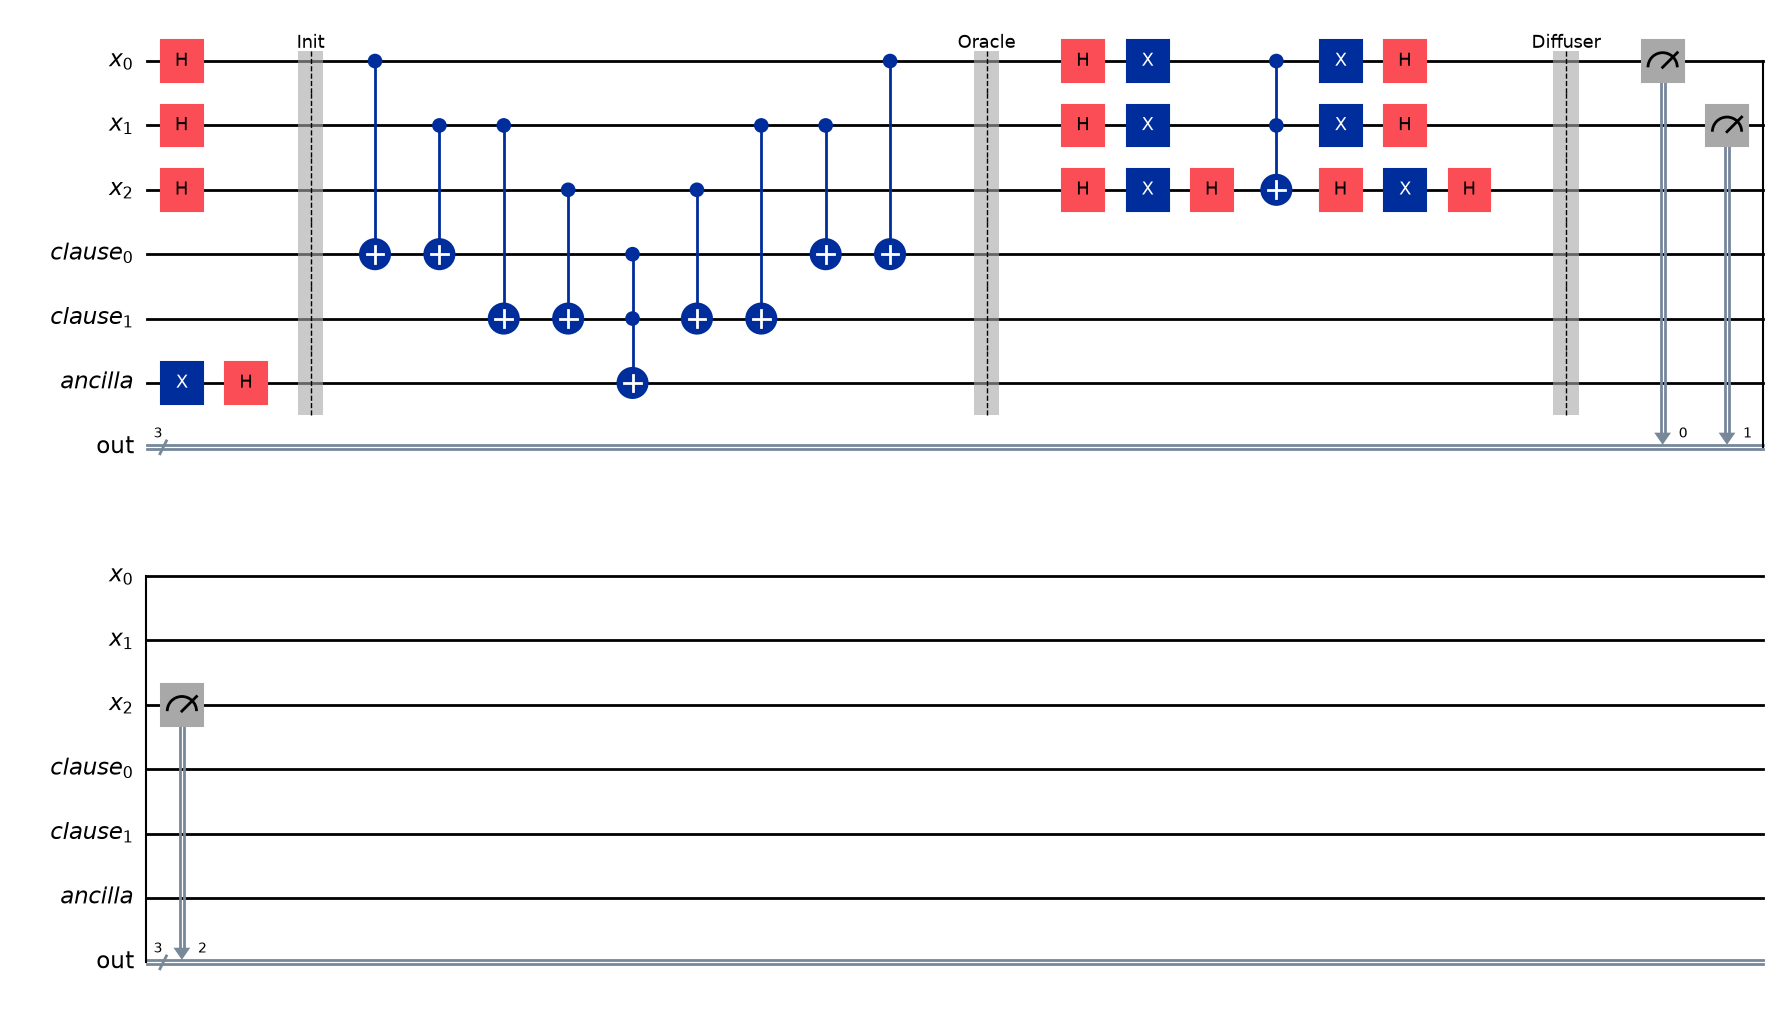

Graph 2-Coloring Measurement Results (4096 shots): {'010': 2024, '101': 2072}


In [7]:
# Graph 2-Coloring SAT Solver via Phase Kickback & Uncomputation

def solve_graph_coloring_grover():
    # Register layout: 3 variables (x0, x1, x2), 2 clause ancillas (c0, c1), 1 phase ancilla (y)
    var = QuantumRegister(3, name='x')
    clause = QuantumRegister(2, name='clause')
    phase_anc = QuantumRegister(1, name='ancilla')
    c_out = ClassicalRegister(3, name='out')
    
    qc_sat = QuantumCircuit(var, clause, phase_anc, c_out, name="Grover_GraphColor")
    
    # 1. State preparation: variables in equal superposition
    qc_sat.h(var)
    
    # 2. Phase ancilla initialized to |-> = H(X|0>)
    qc_sat.x(phase_anc)
    qc_sat.h(phase_anc)
    qc_sat.barrier(label="Init")
    
    # --- GROVER ITERATION (k = 1 for N=8, M=2) ---
    # A. Oracle - Compute Clauses
    # Clause 0: x0 XOR x1 != 0
    qc_sat.cx(var[0], clause[0])
    qc_sat.cx(var[1], clause[0])
    # Clause 1: x1 XOR x2 != 0
    qc_sat.cx(var[1], clause[1])
    qc_sat.cx(var[2], clause[1])
    
    # B. Phase Kickback: Toffoli on ancilla
    qc_sat.ccx(clause[0], clause[1], phase_anc[0])
    
    # C. Uncompute Clauses (Restore ancillas to |0>)
    qc_sat.cx(var[2], clause[1])
    qc_sat.cx(var[1], clause[1])
    qc_sat.cx(var[1], clause[0])
    qc_sat.cx(var[0], clause[0])
    qc_sat.barrier(label="Oracle")
    
    # D. Diffuser on variable register
    qc_sat.h(var)
    qc_sat.x(var)
    qc_sat.h(var[2])
    qc_sat.mcx([var[0], var[1]], var[2])
    qc_sat.h(var[2])
    qc_sat.x(var)
    qc_sat.h(var)
    qc_sat.barrier(label="Diffuser")
    
    # 3. Measure variable qubits
    qc_sat.measure(var, c_out)
    return qc_sat

qc_sat = solve_graph_coloring_grover()
display(qc_sat.draw('mpl', style='iqp'))

# Aer Simulation
sim_backend = AerSimulator()
qc_sat_transpiled = transpile(qc_sat, sim_backend)
counts_sat = sim_backend.run(qc_sat_transpiled, shots=4096).result().get_counts()

print(f"Graph 2-Coloring Measurement Results (4096 shots): {counts_sat}")
plot_histogram(counts_sat, title="Grover SAT Solver: Discovered Valid Colorings |010> and |101>")
plt.show()

## 8. Quantum Counting (BBHT Algorithm: Determining $M$ via QPE)

### 8.1 The Unknown Solutions Dilemma
To apply Grover's algorithm, we must execute $k_{\text{opt}} \approx \frac{\pi}{4}\sqrt{\frac{N}{M}}$ iterations. But in general, the number of satisfying solutions $M$ is **unknown**!
- If we guess $M$ incorrectly, over-rotation can collapse the success probability.
- Can a quantum computer count the number of solutions without evaluating them one by one?

### 8.2 The BBHT Algorithm (Boyer, Brassard, Høyer, Tapp - 1998)
The Grover operator $G$ acts as a pure rotation by angle $\theta$ in the 2D plane:
$$G = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}, \qquad \text{where } \sin\left(\frac{\theta}{2}\right) = \sqrt{\frac{M}{N}}$$

The eigenvalues of $G$ are:
$$\lambda_1 = e^{i\theta}, \qquad \lambda_2 = e^{i(2\pi - \theta)}$$

By applying **Quantum Phase Estimation (QPE)** with $G$ as the unitary operator and $|s\rangle$ as the state:
1. Initialize a counting register of $t$ qubits in equal superposition $H^{\otimes t}|0\rangle$.
2. Apply controlled-$G^{2^j}$ operations onto the state register.
3. Apply the Inverse Quantum Fourier Transform ($\text{QFT}^\dagger$) on the counting register.
4. Measuring the counting register yields an estimate of the phase $\phi = \frac{\theta}{2\pi}$.

From the estimated angle $\theta = 2\pi \frac{\text{measured}}{2^t}$, we directly calculate $M$:
$$M = N \sin^2\left(\frac{\theta}{2}\right)$$

In [8]:
# Quantum Counting via QPE & Inverse QFT (N = 4, M = 1)

def build_counting_circuit(t_qubits=4):
    """
    Constructs a Quantum Counting circuit using QPE on Grover operator G.
    t_qubits: Precision of the counting register.
    """
    # 2-qubit Grover step operator G (Oracle + Diffuser for target |11>)
    def get_grover_step():
        step = QuantumCircuit(2, name="G")
        # Oracle for |11|
        step.cz(0, 1)
        # Diffuser with exact phase
        step.h([0, 1])
        step.x([0, 1])
        step.cz(0, 1)
        step.x([0, 1])
        step.h([0, 1])
        step.global_phase = np.pi  # Exact 2|s><s| - I
        return step

    G_gate = get_grover_step().to_gate()
    cG_gate = G_gate.control(1)

    # Registers
    q_count = QuantumRegister(t_qubits, name='count')
    q_state = QuantumRegister(2, name='state')
    c_out = ClassicalRegister(t_qubits, name='c_count')
    
    qc = QuantumCircuit(q_count, q_state, c_out, name="QuantumCounting")

    # State preparation
    qc.h(q_state)
    qc.h(q_count)

    # Controlled-G^(2^j) powers
    for j in range(t_qubits):
        for _ in range(2**j):
            qc.append(cG_gate, [q_count[j], q_state[0], q_state[1]])

    # Inverse QFT on counting register
    qc.append(QFTGate(t_qubits).inverse(), q_count)
    qc.measure(q_count, c_out)
    return qc

t_prec = 4
qc_count = build_counting_circuit(t_prec)

# Simulate via AerSimulator
sim_backend = AerSimulator()
qc_count_t = transpile(qc_count, sim_backend)
counts_qpe = sim_backend.run(qc_count_t, shots=4096).result().get_counts()

# Process QPE results to estimate M
print("Top Measured Phases from Quantum Counting:")
results_table = []
for bitstring, count in sorted(counts_qpe.items(), key=lambda x: x[1], reverse=True)[:4]:
    measured_int = int(bitstring, 2)
    theta_est = 2 * np.pi * measured_int / (2**t_prec)
    # M = N * sin^2(theta / 2)
    M_est = 4 * (np.sin(theta_est / 2)**2)
    results_table.append({
        "Bitstring": bitstring,
        "Measured Int": measured_int,
        "Phase (rad)": f"{theta_est:.3f}",
        "Estimated M": f"{M_est:.2f}",
        "Counts": count
    })

display(pd.DataFrame(results_table))
plot_histogram(counts_qpe, title="Quantum Counting Register Measurement (Peak indicates eigenvalue)")
plt.show()

Top Measured Phases from Quantum Counting:


,Bitstring,Measured Int,Phase (rad),Estimated M,Counts
0,1101,13,5.105,1.23,1410
1,0011,3,1.178,1.23,1406
2,0010,2,0.785,0.59,371
3,1110,14,5.498,0.59,343


## 9. Hardware Realism & Depolarizing Noise Benchmarking

On physical Noisy Intermediate-Scale Quantum (NISQ) processors, quantum states interact with their environment, undergoing decoherence and gate infidelity:
- **Depth Penalty**: Grover's algorithm requires $k_{\text{opt}} \propto \sqrt{N}$ iterations. In each iteration, multi-controlled gates decompose into dozens of two-qubit CNOT gates.
- **Interference Washout**: As noise accumulates, the constructive interference amplifying the marked state degrades, washing out into the uniform maximally mixed state $\frac{1}{N}I$.

We model physical device noise using **depolarizing noise channels**:
$$\mathcal{E}(\rho) = (1 - p)\rho + \frac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)$$
where 2-qubit gates experience double the error rate of single-qubit gates ($p_{2q} = 2p_{1q}$).

We sweep physical error rate $p \in [0.00, 0.03]$ and measure:
1. Target state detection fidelity.
2. The noise threshold beyond which Grover's advantage is lost.

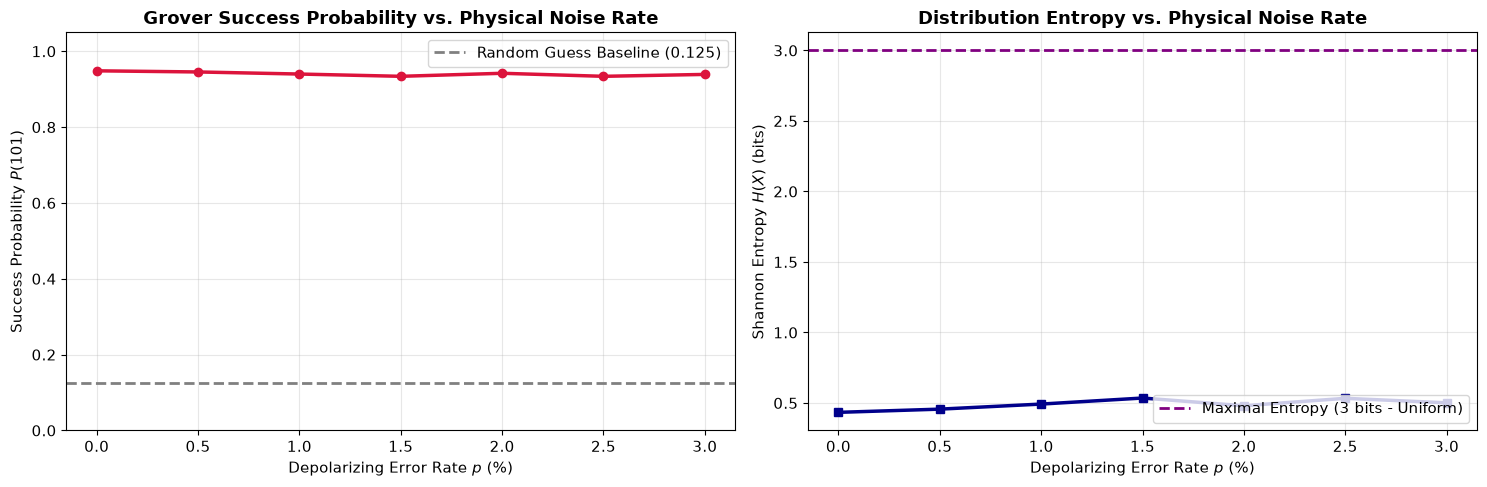

In [9]:
# Hardware Noise Benchmark: 3-Qubit Grover under Depolarizing Noise
def benchmark_grover_noise(target="101", p_rates=np.linspace(0.0, 0.03, 7), shots=2000):
    backend = AerSimulator()
    n_qubits = len(target)
    k_opt = calculate_optimal_iterations(n_qubits, 1)
    
    # Build Grover circuit
    qc = build_grover_circuit([target], n_qubits, iterations=k_opt, measure=True)
    qc_t = transpile(qc, backend)
    
    success_probabilities = []
    shannon_entropies = []
    
    for p in p_rates:
        noise_model = NoiseModel()
        if p > 0:
            err_1q = depolarizing_error(p, 1)
            err_2q = depolarizing_error(min(1.0, 2 * p), 2)
            noise_model.add_all_qubit_quantum_error(err_1q, ['u', 'h', 'x', 'rz', 'sx'])
            noise_model.add_all_qubit_quantum_error(err_2q, ['cx', 'ecr'])
        
        job = backend.run(qc_t, noise_model=noise_model, shots=shots)
        counts = job.result().get_counts()
        
        # Target probability
        p_success = counts.get(target, 0) / shots
        success_probabilities.append(p_success)
        
        # Output Shannon entropy H = -sum(p_i * log2(p_i))
        probs = np.array([c / shots for c in counts.values()])
        entropy = -np.sum(probs * np.log2(probs + 1e-12))
        shannon_entropies.append(entropy)
        
    # Plotting degradation curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Success probability vs error rate
    ax1.plot(p_rates * 100, success_probabilities, marker='o', color='crimson', linewidth=2.5)
    ax1.axhline(1 / (2**n_qubits), color='gray', linestyle='--', label=f"Random Guess Baseline ({1/(2**n_qubits):.3f})")
    ax1.set_title("Grover Success Probability vs. Physical Noise Rate", fontweight='bold')
    ax1.set_xlabel("Depolarizing Error Rate $p$ (%)")
    ax1.set_ylabel(f"Success Probability $P({target})$")
    ax1.set_ylim(0, 1.05)
    ax1.legend(loc='upper right')
    
    # Shannon Entropy vs error rate
    ax2.plot(p_rates * 100, shannon_entropies, marker='s', color='darkblue', linewidth=2.5)
    ax2.axhline(n_qubits, color='purple', linestyle='--', label=f"Maximal Entropy ({n_qubits} bits - Uniform)")
    ax2.set_title("Distribution Entropy vs. Physical Noise Rate", fontweight='bold')
    ax2.set_xlabel("Depolarizing Error Rate $p$ (%)")
    ax2.set_ylabel("Shannon Entropy $H(X)$ (bits)")
    ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

benchmark_grover_noise()

## 10. Complexity Summary, Comparison & Academic References

### 10.1 Algorithm Complexity Comparison
| Metric / Algorithm | Classical Deterministic | Classical Randomized | Grover's Search ($M=1$) | Grover's Search ($M \ge 1$) | Quantum Counting (BBHT) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Worst-Case Query Complexity** | $O(N)$ | $O(N)$ | $O(\sqrt{N})$ | $O(\sqrt{N/M})$ | $O(\sqrt{N})$ |
| **Average Query Complexity** | $N/2$ | $N/2$ | $\frac{\pi}{4}\sqrt{N}$ | $\frac{\pi}{4}\sqrt{N/M}$ | $O(\sqrt{N})$ |
| **Qubit Space Overhead** | $O(n)$ bits | $O(n)$ bits | $n$ qubits | $n$ qubits | $n + t$ qubits |
| **Success Probability** | $100\%$ | $1 - (1 - 1/N)^k$ | $\ge 1 - 1/N$ | $\approx 100\%$ | High confidence |
| **Optimality Bound** | Classical Bound: $\Omega(N)$ | Classical Bound: $\Omega(N)$ | BBBV Bound: $\Omega(\sqrt{N})$ | Optimal | Optimal for counting |


---

### 10.3 Academic References
1. **Grover, L. K.** (1996). *A fast quantum mechanical algorithm for database search*. In Proceedings of the twenty-eighth annual ACM symposium on Theory of computing (STOC '96), pp. 212–219. [DOI: 10.1145/237814.237866](https://doi.org/10.1145/237814.237866)
2. **Boyer, M., Brassard, G., Høyer, P., & Tapp, A.** (1998). *Tight bounds on quantum searching*. Fortschritte der Physik: Progress of Physics, 46(4-5), 493–505.
3. **Bennett, C. H., Bernstein, E., Brassard, G., & Vazirani, U.** (1997). *Strengths and weaknesses of quantum computing*. SIAM Journal on Computing, 26(5), 1510–1523. (BBBV Bound).
4. **Brassard, G., Høyer, P., Mosca, M., & Tapp, A.** (2002). *Quantum amplitude amplification and estimation*. Contemporary Mathematics, 305, 53–74.
5. **Nielsen, M. A., & Chuang, I. L.** (2010). *Quantum Computation and Quantum Information: 10th Anniversary Edition*. Cambridge University Press.